# Communication-efficient algorithms

Start a fresh kernel, then Run all: the first cell configures 4 logical CPU devices before backend initialization so you can practice multi-device sharding locally.

- Compare all-reduce and reduce-scatter against the same independent global gradient.
- Explain global result shape versus per-device storage.
- Account for a subsequent all-gather before claiming a communication saving.

Every device computed a partial gradient. Does every device need the complete result immediately? We will implement an all-reduce and a reduce-scatter on four logical CPU devices, prove they represent the same global gradient, and account for when a later all-gather gives the communication back.

## The idea

A collective combines or redistributes values among participants. Track chunk identity and reduction state at each stage to understand what the operation achieves. Communication volume also depends on the assumed algorithm.

## Track reduced chunks through communication

Reduce-scatter combines contributions and leaves each participant with its assigned portion of the result. An all-gather can then distribute those portions so each holds the full result. Together they can implement the corresponding all-reduce.

Distinguish an original contribution from a chunk whose contributions have already been combined. Sending values and reducing values are different actions, even when arrows look similar.

The byte bars are modeled payloads under the lesson's assumptions. They do not capture all protocol overhead or establish physical overlap. Use them to predict a tradeoff, then measure the actual topology if network performance is the question.

### Reduce-scatter followed by all-gather

**Predict:** Does every participant hold the complete reduced array after reduce-scatter?

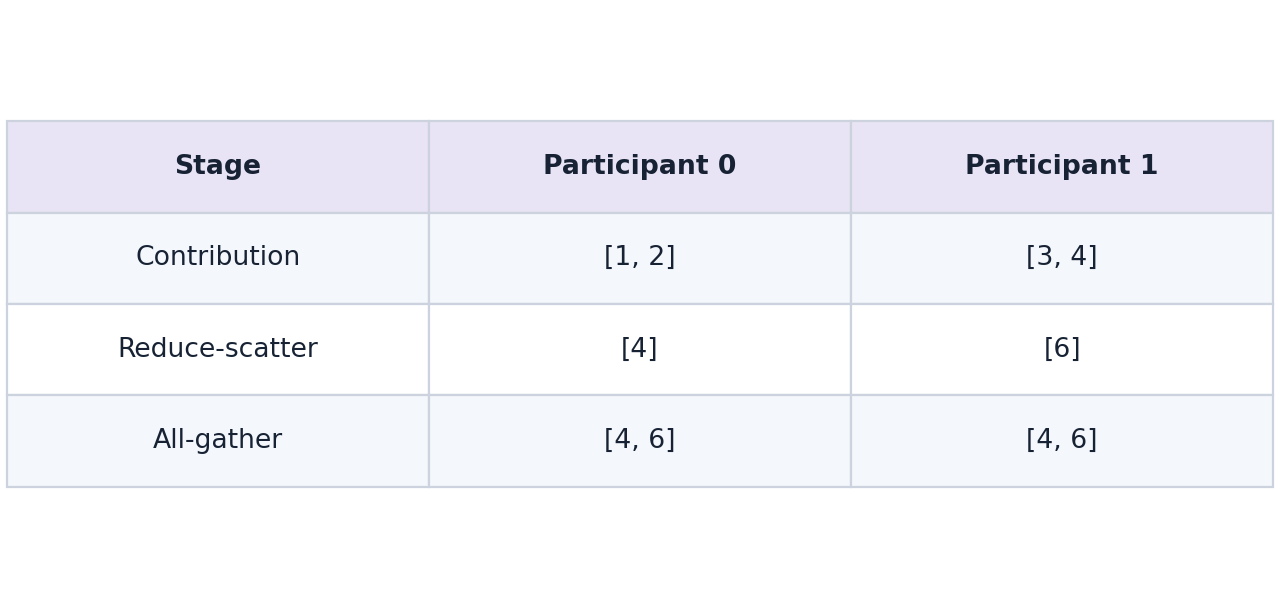

*Conceptual / analytic teaching diagram; not a recorded benchmark.*

Contributions $[1,2]$ and $[3,4]$ are summed into portions $[4]$ and $[6]$. After reduce-scatter neither participant holds the full result. All-gather then gives each $[4,6]$. This analytic example shows ownership, not a physical schedule or measured traffic.

### Pause and reason

Does every participant hold the complete reduced array after reduce-scatter?

<details><summary>Compare your reasoning</summary>

No. Each holds its reduced portion. Replicating the complete result requires the appropriate gather stage or another collective contract.

</details>

## Keep normalization independent of device count

Our regression problem has sixteen observations and eight weights. Each of four devices receives four observations. Inside shard_map, the local function sees that local batch, but its gradient contribution still divides by the global count $N=16$. Summing those contributions produces the derivative of the global mean loss. Dividing by the local count and summing would multiply the gradient by four. The NumPy expression calculates the complete derivative without JAX collectives.

$$
g_r=\frac{2}{N}X_r^\mathsf{T}(X_rw-y_r),\qquad g=\sum_{r=0}^{p-1}g_r,\qquad N=16,\quad p=4
$$

## Read the local result before interpreting the global array

Both programs return a global vector with shape $(8,)$. With all-reduce, each device holds all eight values; the output specification is `P()`. With reduce-scatter, each holds two consecutive values; `P("data")` describes how these pieces form the global vector. The full-array NumPy comparison checks values, while inspecting addressable shards checks storage. A shape print alone cannot distinguish these results.

## Derive a communication model with its assumptions visible

Let $G$ be the byte size of one complete gradient and $p$ the number of ranks. In an idealized ring, reduce-scatter sends a total of $(p-1)G/p$ bytes per rank. A subsequent all-gather sends the same amount. Their sum gives the usual two-phase ring all-reduce payload. For eight float32 values, $G=32$ bytes and $p=4$: the modeled payloads are twenty-four and forty-eight bytes per rank. These are algorithmic payload counts, not measured traffic or total memory use. They omit latency, protocol overhead and topology.

$$
B_{\mathrm{RS}}=\frac{p-1}{p}G,\qquad B_{\mathrm{AG}}=\frac{p-1}{p}G,\qquad B_{\mathrm{AR}}=2\frac{p-1}{p}G
$$

## Follow the consumer of the gradient

An elementwise optimizer can update matching parameter and momentum slices using a gradient slice. This can reduce persistent per-device optimizer storage. But if the next forward pass expects replicated weights, those updated weights still need gathering. Reducing one collective does not automatically reduce the communication of a whole training step.

Our example implements the gather explicitly and checks the reconstructed vector. In installed JAX 0.9.2, the default all_gather variation rule does not infer the replicated output required here. Only this small wrapper sets check_vma=False; its proof is that every rank gathers the same ordered slices. The code verifies every local replica as well as the global reference. Do not disable variation checks to conceal a genuinely rank-dependent output.

## Separate observed execution from the payload model and run on a TPU mesh

The lowered StableHLO is inspected for the requested collective operations. The benchmark warms each exact function and waits for every result; it prints seven CPU timing samples summarized by their medians. Compilation is excluded. These logical devices share one host and do not reproduce a TPU network.

A reduce-scatter may time slower than an all-reduce on this tiny workload. That observation does not invalidate the byte calculation: timing also depends on dispatch, implementation and synchronization. The separate gather timing is an isolated call; summing isolated medians is not a measured fused training-step latency. Benchmark the complete consuming algorithm on its actual hardware before reporting a system improvement. When you run this lesson on a 4-chip TPU VM (`v5litepod-4` or `v6e-4`) from the TPU course (`phase-tpu`), remove the CPU platform override so `shard_map` lowers `psum` and `psum_scatter` onto physical TPU ICI links.

**Run all-reduce and reduce-scatter across 4 TPU chips on a TPU VM**

```bash
gcloud compute tpus tpu-vm scp exercises/distributed-03.py $TPU_NAME:~/jax-tpu-lab/ --zone=$ZONE
gcloud compute tpus tpu-vm ssh $TPU_NAME --zone=$ZONE \
  --command="sed \"s/jax.config.update('jax_platforms', 'cpu')/# use default TPU backend/; s/jax.config.update('jax_num_cpu_devices', 4)/# use physical TPU chips/\" ~/jax-tpu-lab/distributed-03.py > ~/jax-tpu-lab/distributed-03-tpu.py && JAX_PLATFORMS=tpu ~/jax-tpu-lab/.venv/bin/python ~/jax-tpu-lab/distributed-03-tpu.py"
```

**Expected:** Verifies that all_reduce, reduce_scatter, and all_gather match the NumPy reference across 4 physical TPU devices and prints completed TPU median microseconds.

## Configure four logical devices

Add this block after the preceding block in a fresh Python file, then run the complete file.

In [1]:
# Step 1 — Configure four logical devices: Compare both the numerical global result and the placement needed...
# Import jax for this computation.
import jax
# Update state in place with the new values.
jax.config.update('jax_platforms', 'cpu')
# Update state in place with the new values.
jax.config.update('jax_num_cpu_devices', 4)
# Import jax.numpy for this computation.
import jax.numpy as jnp
import numpy as np
from jax.sharding import Mesh, NamedSharding, PartitionSpec as P
from time import perf_counter

Compare both the numerical global result and the placement needed by its next consumer.

## Place the data and model

Add this block after the preceding block in a fresh Python file, then run the complete file.

In [2]:
# Step 2 — Place the data and model: Compare both the numerical global result and the placement needed...
# Assert invariant `jax.local_device_count() == 4` holds
assert jax.local_device_count() == 4, 'Restart with four logical CPU devices'
# Configure multi-device placement / sharding specification (`mesh`).
mesh = Mesh(np.asarray(jax.devices()), ('data',))
# Configure multi-device placement / sharding specification (`rows`).
rows = NamedSharding(mesh, P('data', None))
# Configure multi-device placement / sharding specification (`replicated`).
replicated = NamedSharding(mesh, P())
# Configure multi-device placement / sharding specification (`features`).
features = NamedSharding(mesh, P('data'))
# Construct and reshape `xh` into the target tensor dimensions.
xh = np.arange(16 * 8, dtype=np.float32).reshape(16, 8) / 128 - 0.5
# Compute `yh` from `xh @ np.linspace(-0.4, 0.3, 8, dtype=np.float32)`
yh = xh @ np.linspace(-0.4, 0.3, 8, dtype=np.float32)
# Compute `wh` from `np.linspace(0.1, -0.2, 8, dtype=np.float32)`
wh = np.linspace(0.1, -0.2, 8, dtype=np.float32)
# Place `x` explicitly onto the target JAX device.
x = jax.device_put(xh, rows)
# Configure multi-device placement / sharding specification (`y`).
y = jax.device_put(yh, NamedSharding(mesh, P('data')))
# Place `w` explicitly onto the target JAX device.
w = jax.device_put(wh, replicated)

Compare both the numerical global result and the placement needed by its next consumer.

## Implement partial gradients and collectives

Add this block after the preceding block in a fresh Python file, then run the complete file.

In [3]:
# Step 3 — Implement partial gradients and collectives: Compare both the numerical global result and the placement needed...
def local_contribution(a, b, weights):
    # Return `2 * a.T @ (a @ weights - b) / 16` to the caller.
    return 2 * a.T @ (a @ weights - b) / 16

Compare both the numerical global result and the placement needed by its next consumer.

## Verify the result and placement

Add this block after the preceding block in a fresh Python file, then run the complete file.

In [4]:
# Step 4 — Verify the result and placement: Compare both the numerical global result and the placement needed...
def reduce_all(a, b, weights):
    # Return `jax.lax.psum(local_contribution(a, b, weights), 'data')` to the caller.
    return jax.lax.psum(local_contribution(a, b, weights), 'data')

Compare both the numerical global result and the placement needed by its next consumer.

## Measure completed calls

Add this block after the preceding block in a fresh Python file, then run the complete file.

In [5]:
# Step 5 — Measure completed calls: Compare both the numerical global result and the placement needed...
def reduce_shard(a, b, weights):
    # Return `jax.lax.psum_scatter(local_contribution(a, b, weights), 'data', tiled=True)` to the caller.
    return jax.lax.psum_scatter(local_contribution(a, b, weights), 'data', tiled=True)

Compare both the numerical global result and the placement needed by its next consumer.

## Measure completed calls

Add this block after the preceding block in a fresh Python file, then run the complete file.

In [6]:
# Step 6 — Measure completed calls: Compare both the numerical global result and the placement needed...
# Configure multi-device placement / sharding specification (`all_gradient`).
all_gradient = jax.jit(jax.shard_map(reduce_all, mesh=mesh,
    in_specs=(P('data', None), P('data'), P()), out_specs=P()))
# Configure multi-device placement / sharding specification (`shard_gradient`).
shard_gradient = jax.jit(jax.shard_map(reduce_shard, mesh=mesh,
    in_specs=(P('data', None), P('data'), P()), out_specs=P('data')))
# Configure multi-device placement / sharding specification (`gather`).
gather = jax.jit(jax.shard_map(lambda g: jax.lax.all_gather(g, 'data', tiled=True),
    mesh=mesh, in_specs=P('data'), out_specs=P(), check_vma=False))
# Run `all_gradient` to compute `ga`.
ga = all_gradient(x, y, w)
# Run `shard_gradient` to compute `gs`.
gs = shard_gradient(x, y, w)
# Run `gather` to compute `gg`.
gg = gather(gs)
# Perform matrix contraction / projection to compute `reference`.
reference = 2 * xh.T @ (xh @ wh - yh) / 16
# Iterate over `result` to step through the computation:
for result in [ga, gs, gg]:
    # Convert `` to a host NumPy array for inspection or verification.
    np.testing.assert_allclose(np.asarray(result), reference, atol=2e-6, rtol=2e-6)
# Check tensor shape invariant: `all(s.data.shape == (8,) for s in ga.addressable_shards)`
assert all(s.data.shape == (8,) for s in ga.addressable_shards)
# Check tensor shape invariant: `all(s.data.shape == (2,) for s in gs.addressable_shards)`
assert all(s.data.shape == (2,) for s in gs.addressable_shards)
# Check tensor shape invariant: `all(s.data.shape == (8,) for s in gg.addressable_shards)`
assert all(s.data.shape == (8,) for s in gg.addressable_shards)
# Trace or lower the function to inspect its compiler representation (`hlo_all`).
hlo_all = str(all_gradient.lower(x, y, w).compiler_ir(dialect='stablehlo'))
# Run `str` to compute `hlo_shard`.
hlo_shard = str(shard_gradient.lower(x, y, w).compiler_ir(dialect='stablehlo'))
# Assert invariant `'all_reduce' in hlo_all and 'reduce_scatter' in hlo_shard` holds
assert 'all_reduce' in hlo_all and 'reduce_scatter' in hlo_shard

Compare both the numerical global result and the placement needed by its next consumer.

## Measure completed calls

Add this block after the preceding block in a fresh Python file, then run the complete file.

In [7]:
# Step 7 — Measure completed calls: Compare both the numerical global result and the placement needed...
def completed_samples(fn, *args):
    # Synchronize host execution until asynchronous device computation completes.
    fn(*args).block_until_ready()
    # Compute `samples` from `[]`
    samples = []
    # Repeat the update loop over `range(7)` steps:
    for _ in range(7):
        # Record execution timing or profiler trace in `start`.
        start = perf_counter()
        # Synchronize host execution until asynchronous device computation completes.
        fn(*args).block_until_ready()
        # Record execution timing or profiler trace in ``.
        samples.append((perf_counter() - start) * 1e6)
    # Return `samples` to the caller.
    return samples
# Run `completed_samples` to compute `all_us`.
all_us = completed_samples(all_gradient, x, y, w)
# Run `completed_samples` to compute `shard_us`.
shard_us = completed_samples(shard_gradient, x, y, w)
# Run `completed_samples` to compute `gather_us`.
gather_us = completed_samples(gather, gs)
# Idealized ring payload per rank; not a network measurement.
ranks, gradient_bytes = 4, wh.nbytes
# Compute `ring_scatter_bytes` from `(ranks - 1) / ranks * gradient_bytes`
ring_scatter_bytes = (ranks - 1) / ranks * gradient_bytes
# Compute `ring_all_bytes` from `2 * ring_scatter_bytes`
ring_all_bytes = 2 * ring_scatter_bytes
# Print the observed values to compare against the expected result.
print('Gradient reference:', reference.tolist())
# Print diagnostic summary of the computed outputs.
print('Local result shapes: replicated (8,), reduce-scatter (2,), gathered (8,)')
# Print diagnostic summary of the computed outputs.
print('Idealized ring bytes per rank:', ring_all_bytes, ring_scatter_bytes)
# Print diagnostic summary of the computed outputs.
print('Completed CPU median microseconds:', {
    'all_reduce': float(np.median(all_us)), 'reduce_scatter': float(np.median(shard_us)),
    'all_gather_only': float(np.median(gather_us))})

Gradient reference: [0.0029296851716935635, 0.00219726306386292, 0.0014648411888629198, 0.0007324193138629198, -2.6193447411060333e-09, -0.000732424552552402, -0.001464846427552402, -0.002197268418967724]
Local result shapes: replicated (8,), reduce-scatter (2,), gathered (8,)
Idealized ring bytes per rank: 48.0 24.0
Completed CPU median microseconds: {'all_reduce': 94.54227983951569, 'reduce_scatter': 89.37530219554901, 'all_gather_only': 90.99999442696571}


Compare both the numerical global result and the placement needed by its next consumer.

## Run the example

In [8]:
# Step 1 — Configure four logical devices: Compare both the numerical global result and the placement needed...
# Import jax for this computation.
import jax
# Update state in place with the new values.
jax.config.update('jax_platforms', 'cpu')
# Update state in place with the new values.
jax.config.update('jax_num_cpu_devices', 4)
# Import jax.numpy for this computation.
import jax.numpy as jnp
import numpy as np
from jax.sharding import Mesh, NamedSharding, PartitionSpec as P
from time import perf_counter

# Step 2 — Place the data and model: Compare both the numerical global result and the placement needed...
# Assert invariant `jax.local_device_count() == 4` holds
assert jax.local_device_count() == 4, 'Restart with four logical CPU devices'
# Configure multi-device placement / sharding specification (`mesh`).
mesh = Mesh(np.asarray(jax.devices()), ('data',))
# Configure multi-device placement / sharding specification (`rows`).
rows = NamedSharding(mesh, P('data', None))
# Configure multi-device placement / sharding specification (`replicated`).
replicated = NamedSharding(mesh, P())
# Configure multi-device placement / sharding specification (`features`).
features = NamedSharding(mesh, P('data'))
# Construct and reshape `xh` into the target tensor dimensions.
xh = np.arange(16 * 8, dtype=np.float32).reshape(16, 8) / 128 - 0.5
# Compute `yh` from `xh @ np.linspace(-0.4, 0.3, 8, dtype=np.float32)`
yh = xh @ np.linspace(-0.4, 0.3, 8, dtype=np.float32)
# Compute `wh` from `np.linspace(0.1, -0.2, 8, dtype=np.float32)`
wh = np.linspace(0.1, -0.2, 8, dtype=np.float32)
# Place `x` explicitly onto the target JAX device.
x = jax.device_put(xh, rows)
# Configure multi-device placement / sharding specification (`y`).
y = jax.device_put(yh, NamedSharding(mesh, P('data')))
# Place `w` explicitly onto the target JAX device.
w = jax.device_put(wh, replicated)

# Step 3 — Implement partial gradients and collectives: Compare both the numerical global result and the placement needed...
def local_contribution(a, b, weights):
    # Return `2 * a.T @ (a @ weights - b) / 16` to the caller.
    return 2 * a.T @ (a @ weights - b) / 16

# Step 4 — Verify the result and placement: Compare both the numerical global result and the placement needed...
def reduce_all(a, b, weights):
    # Return `jax.lax.psum(local_contribution(a, b, weights), 'data')` to the caller.
    return jax.lax.psum(local_contribution(a, b, weights), 'data')

# Step 5 — Measure completed calls: Compare both the numerical global result and the placement needed...
def reduce_shard(a, b, weights):
    # Return `jax.lax.psum_scatter(local_contribution(a, b, weights), 'data', tiled=True)` to the caller.
    return jax.lax.psum_scatter(local_contribution(a, b, weights), 'data', tiled=True)

# Step 6 — Measure completed calls: Compare both the numerical global result and the placement needed...
# Configure multi-device placement / sharding specification (`all_gradient`).
all_gradient = jax.jit(jax.shard_map(reduce_all, mesh=mesh,
    in_specs=(P('data', None), P('data'), P()), out_specs=P()))
# Configure multi-device placement / sharding specification (`shard_gradient`).
shard_gradient = jax.jit(jax.shard_map(reduce_shard, mesh=mesh,
    in_specs=(P('data', None), P('data'), P()), out_specs=P('data')))
# Configure multi-device placement / sharding specification (`gather`).
gather = jax.jit(jax.shard_map(lambda g: jax.lax.all_gather(g, 'data', tiled=True),
    mesh=mesh, in_specs=P('data'), out_specs=P(), check_vma=False))
# Run `all_gradient` to compute `ga`.
ga = all_gradient(x, y, w)
# Run `shard_gradient` to compute `gs`.
gs = shard_gradient(x, y, w)
# Run `gather` to compute `gg`.
gg = gather(gs)
# Perform matrix contraction / projection to compute `reference`.
reference = 2 * xh.T @ (xh @ wh - yh) / 16
# Iterate over `result` to step through the computation:
for result in [ga, gs, gg]:
    # Convert `` to a host NumPy array for inspection or verification.
    np.testing.assert_allclose(np.asarray(result), reference, atol=2e-6, rtol=2e-6)
# Check tensor shape invariant: `all(s.data.shape == (8,) for s in ga.addressable_shards)`
assert all(s.data.shape == (8,) for s in ga.addressable_shards)
# Check tensor shape invariant: `all(s.data.shape == (2,) for s in gs.addressable_shards)`
assert all(s.data.shape == (2,) for s in gs.addressable_shards)
# Check tensor shape invariant: `all(s.data.shape == (8,) for s in gg.addressable_shards)`
assert all(s.data.shape == (8,) for s in gg.addressable_shards)
# Trace or lower the function to inspect its compiler representation (`hlo_all`).
hlo_all = str(all_gradient.lower(x, y, w).compiler_ir(dialect='stablehlo'))
# Run `str` to compute `hlo_shard`.
hlo_shard = str(shard_gradient.lower(x, y, w).compiler_ir(dialect='stablehlo'))
# Assert invariant `'all_reduce' in hlo_all and 'reduce_scatter' in hlo_shard` holds
assert 'all_reduce' in hlo_all and 'reduce_scatter' in hlo_shard

# Step 7 — Measure completed calls: Compare both the numerical global result and the placement needed...
def completed_samples(fn, *args):
    # Synchronize host execution until asynchronous device computation completes.
    fn(*args).block_until_ready()
    # Compute `samples` from `[]`
    samples = []
    # Repeat the update loop over `range(7)` steps:
    for _ in range(7):
        # Record execution timing or profiler trace in `start`.
        start = perf_counter()
        # Synchronize host execution until asynchronous device computation completes.
        fn(*args).block_until_ready()
        # Record execution timing or profiler trace in ``.
        samples.append((perf_counter() - start) * 1e6)
    # Return `samples` to the caller.
    return samples
# Run `completed_samples` to compute `all_us`.
all_us = completed_samples(all_gradient, x, y, w)
# Run `completed_samples` to compute `shard_us`.
shard_us = completed_samples(shard_gradient, x, y, w)
# Run `completed_samples` to compute `gather_us`.
gather_us = completed_samples(gather, gs)
# Idealized ring payload per rank; not a network measurement.
ranks, gradient_bytes = 4, wh.nbytes
# Compute `ring_scatter_bytes` from `(ranks - 1) / ranks * gradient_bytes`
ring_scatter_bytes = (ranks - 1) / ranks * gradient_bytes
# Compute `ring_all_bytes` from `2 * ring_scatter_bytes`
ring_all_bytes = 2 * ring_scatter_bytes
# Print the observed values to compare against the expected result.
print('Gradient reference:', reference.tolist())
# Print diagnostic summary of the computed outputs.
print('Local result shapes: replicated (8,), reduce-scatter (2,), gathered (8,)')
# Print diagnostic summary of the computed outputs.
print('Idealized ring bytes per rank:', ring_all_bytes, ring_scatter_bytes)
# Print diagnostic summary of the computed outputs.
print('Completed CPU median microseconds:', {
    'all_reduce': float(np.median(all_us)), 'reduce_scatter': float(np.median(shard_us)),
    'all_gather_only': float(np.median(gather_us))})

Gradient reference: [0.0029296851716935635, 0.00219726306386292, 0.0014648411888629198, 0.0007324193138629198, -2.6193447411060333e-09, -0.000732424552552402, -0.001464846427552402, -0.002197268418967724]
Local result shapes: replicated (8,), reduce-scatter (2,), gathered (8,)
Idealized ring bytes per rank: 48.0 24.0
Completed CPU median microseconds: {'all_reduce': 98.41565042734146, 'reduce_scatter': 78.20827886462212, 'all_gather_only': 74.3749551475048}


Expected: All three global gradients agree with NumPy. The replicated and reconstructed local results contain eight values each; reduce-scatter shards contain two. The idealized ring payload is 48 bytes per rank for all-reduce and 24 for reduce-scatter. Actual CPU timing samples vary.

## One mathematical gradient, different local storage

Predict: Will equal global gradients imply equal numbers of stored values on each device?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [9]:
# Compute figure data for: One mathematical gradient, different local storage
# Compute `visual_data` from `{'panels':[{'kind':'bar','labels':['all-reduce','red...`
visual_data={'panels':[{'kind':'bar','labels':['all-reduce','reduce-scatter','after gather'],'ylabel':'values stored per device','series':[{'label':'observed local shape','y':[ga.addressable_shards[0].data.size,gs.addressable_shards[0].data.size,gg.addressable_shards[0].data.size]}]},{'kind':'bar','labels':['all-reduce','reduce-scatter','scatter + gather'],'ylabel':'modeled bytes per rank','series':[{'label':'idealized ring payload','y':[ring_all_bytes,ring_scatter_bytes,ring_scatter_bytes*2]}]}]}

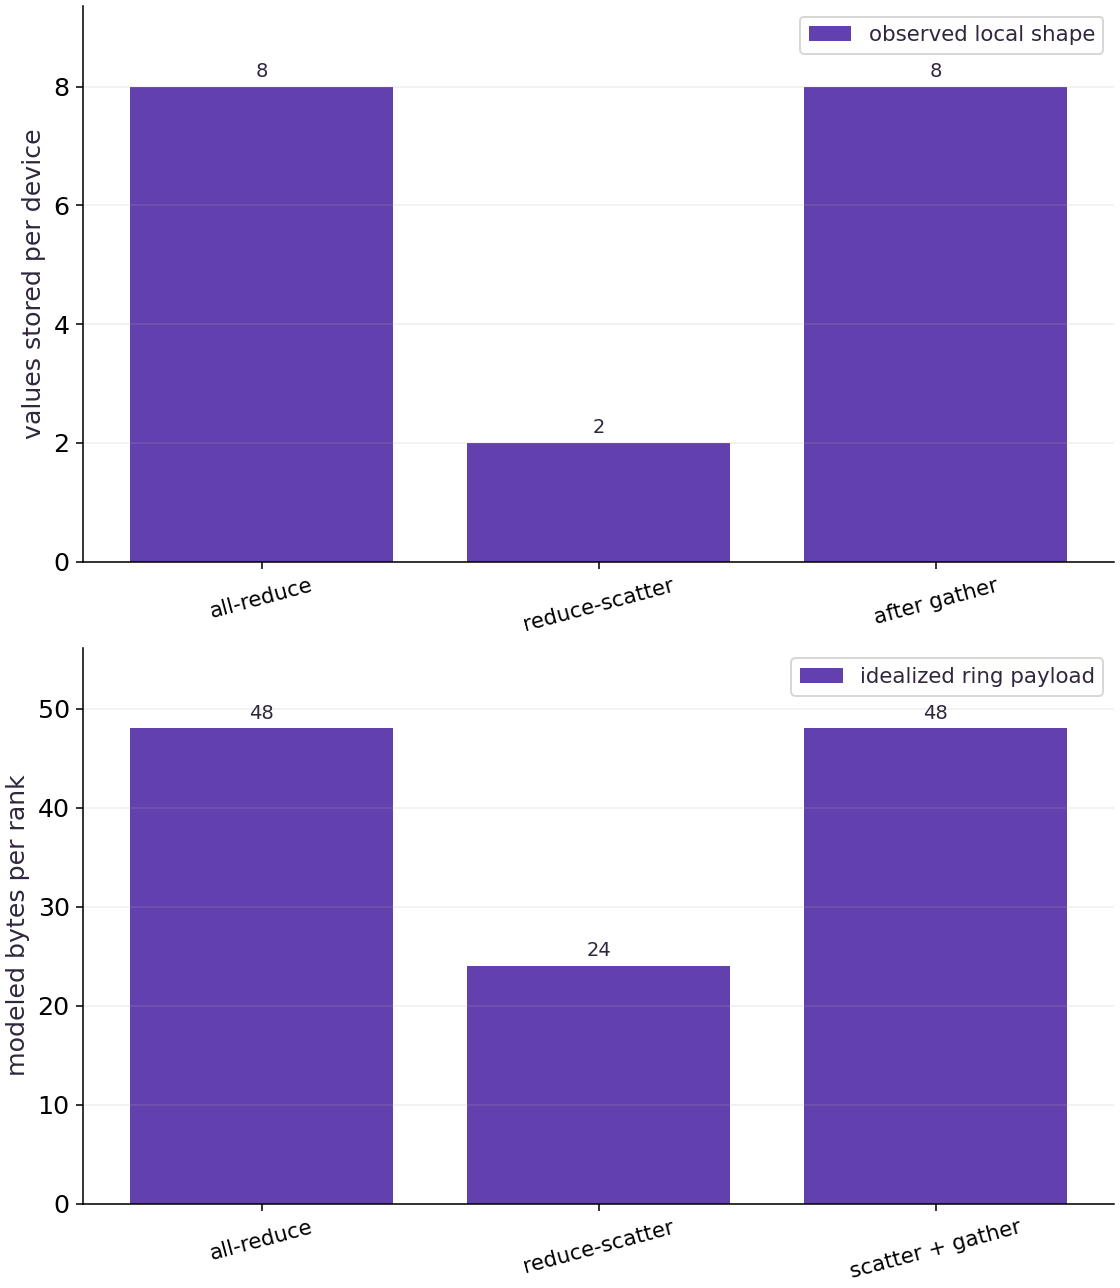

In [10]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The upper panel counts values in one local result: eight for all-reduce, two for reduce-scatter, and eight after gathering. These counts come from actual addressable shards. All three global vectors contain the same eight gradient values. The lower panel shows the idealized ring payload in bytes per rank: forty-eight for all-reduce, twenty-four for reduce-scatter alone, and forty-eight when gathering is added. It is a model, not measured device traffic.

### Connect it to the computation

The reduction in the middle storage bar comes from partitioning the summed gradient. The return of both bars after gathering explains why a local memory benefit and a complete communication benefit are different claims. The momentum experiment consumes slices before reconstructing weights. Its numerical comparison checks correctness; the separate synchronized CPU samples check a different question and is distinct from accelerator speed.

## Update slices before gathering

Predict: Can elementwise momentum produce the same update while its state remains partitioned?

In [11]:
# Experiment — Update slices before gathering: An elementwise update can consume the partitioned gradient.
# Compute `v_host` from `np.linspace(-0.02, 0.03, 8, dtype=np.float32)`
v_host = np.linspace(-0.02, 0.03, 8, dtype=np.float32)
# Place `ws` explicitly onto the target JAX device.
ws = jax.device_put(wh, features)
# Place `vs` explicitly onto the target JAX device.
vs = jax.device_put(v_host, features)
# Compute `new_v` from `0.9 * vs + gs`
new_v = 0.9 * vs + gs
# Compute `new_w` from `ws - 0.1 * new_v`
new_w = ws - 0.1 * new_v
# Run `gather` to compute `updated`.
updated = gather(new_w)
# Compute `expected_w` from `wh - 0.1 * (0.9 * v_host + reference)`
expected_w = wh - 0.1 * (0.9 * v_host + reference)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(np.asarray(updated), expected_w, atol=2e-6, rtol=2e-6)
# Iterate over `shard` to step through the computation:
for shard in updated.addressable_shards:
    # Convert `` to a host NumPy array for inspection or verification.
    np.testing.assert_allclose(np.asarray(shard.data), expected_w, atol=2e-6, rtol=2e-6)
# Check tensor shape invariant: `all(s.data.shape == (2,) for s in new_v.addressable_shards)`
assert all(s.data.shape == (2,) for s in new_v.addressable_shards)
# Print diagnostic summary of the computed outputs.
print('Sharded momentum matches the independent elementwise update.')

Sharded momentum matches the independent elementwise update.


Expected: The gathered update matches the independent momentum formula, while local momentum retains two values.

An elementwise update can consume the partitioned gradient. Gathering the updated parameter later is still real communication, so include it when evaluating the full algorithm.

## Your exercise

Repeat the gradient comparison after reversing both observation rows and labels and changing the initial weights. Verify every all-reduce and reconstructed local replica, then explain why reversing only the labels changes the problem.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `Mesh + PartitionSpec + NamedSharding` — Maps logical tensor axes onto physical device mesh axes for SPMD data, tensor, or pipeline parallelism.

**Step-by-step implementation plan:**
1. Configure multi-device placement / sharding specification (`y2`).
2. Cast or evaluate `w2h` in explicit floating-point precision.
3. Place `w2` explicitly onto the target JAX device.
4. Perform matrix contraction / projection to compute `r2`.
5. Iterate over `answer` to step through the computation:

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Repeat the gradient comparison after reversing both observation rows...
x2 = jax.device_put(...)  # TODO: compute x2
# Configure multi-device placement / sharding specification (`y2`).
y2 = jax.device_put(...)  # TODO: compute y2
# Cast or evaluate `w2h` in explicit floating-point precision.
w2h = ...  # TODO: compute w2h
# Place `w2` explicitly onto the target JAX device.
w2 = jax.device_put(...)  # TODO: compute w2
# Perform matrix contraction / projection to compute `r2`.
r2 = ...  # TODO: compute r2
# Iterate over `answer` to step through the computation:
for answer in [all_gradient(x2, y2, w2), gather(shard_gradient(x2, y2, w2))]:
    # Convert `` to a host NumPy array for inspection or verification.
    np.testing.assert_allclose(np.asarray(answer), r2, atol = ...  # TODO: compute np.testing.assert_allclose(np.asarray(answer), r2, atol
    # Iterate over `shard` to step through the computation:
    for shard in answer.addressable_shards:
        # Convert `` to a host NumPy array for inspection or verification.
        np.testing.assert_allclose(np.asarray(shard.data), r2, atol = ...  # TODO: compute np.testing.assert_allclose(np.asarray(shard.data), r2, atol
# Perform matrix contraction / projection to compute `wrong_labels`.
wrong_labels = ...  # TODO: compute wrong_labels
# Check numerical equivalence within tolerance: `np.max(np.abs(wrong_labels-r2)) > 0.01`
assert np.max(np.abs(wrong_labels-r2))  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
print('Joint permutation preserves the gradient; label-only reversal does not.')
```

In [12]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Repeat the gradient comparison after reversing both observation rows...
# x2 = jax.device_put(...)  # TODO: compute x2
# Configure multi-device placement / sharding specification (`y2`).
# y2 = jax.device_put(...)  # TODO: compute y2
# Cast or evaluate `w2h` in explicit floating-point precision.
# w2h = ...  # TODO: compute w2h
# Place `w2` explicitly onto the target JAX device.
# w2 = jax.device_put(...)  # TODO: compute w2
# Perform matrix contraction / projection to compute `r2`.
# r2 = ...  # TODO: compute r2
# Iterate over `answer` to step through the computation:
# for answer in [all_gradient(x2, y2, w2), gather(shard_gradient(x2, y2, w2))]:
    # Convert `` to a host NumPy array for inspection or verification.
#     np.testing.assert_allclose(np.asarray(answer), r2, atol = ...  # TODO: compute np.testing.assert_allclose(np.asarray(answer), r2, atol
    # Iterate over `shard` to step through the computation:
#     for shard in answer.addressable_shards:
        # Convert `` to a host NumPy array for inspection or verification.
#         np.testing.assert_allclose(np.asarray(shard.data), r2, atol = ...  # TODO: compute np.testing.assert_allclose(np.asarray(shard.data), r2, atol
# Perform matrix contraction / projection to compute `wrong_labels`.
# wrong_labels = ...  # TODO: compute wrong_labels
# Check numerical equivalence within tolerance: `np.max(np.abs(wrong_labels-r2)) > 0.01`
# assert np.max(np.abs(wrong_labels-r2))  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
# print('Joint permutation preserves the gradient; label-only reversal does not.')

## Reference solution

Try your own implementation first.

In [13]:
# Exercise solution: Repeat the gradient comparison after reversing both observation rows...
x2 = jax.device_put(xh[::-1].copy(), rows)
# Configure multi-device placement / sharding specification (`y2`).
y2 = jax.device_put(yh[::-1].copy(), NamedSharding(mesh, P('data')))
# Cast or evaluate `w2h` in explicit floating-point precision.
w2h = wh + np.float32(0.17)
# Place `w2` explicitly onto the target JAX device.
w2 = jax.device_put(w2h, replicated)
# Perform matrix contraction / projection to compute `r2`.
r2 = 2 * xh.T @ (xh @ w2h - yh) / 16
# Iterate over `answer` to step through the computation:
for answer in [all_gradient(x2, y2, w2), gather(shard_gradient(x2, y2, w2))]:
    # Convert `` to a host NumPy array for inspection or verification.
    np.testing.assert_allclose(np.asarray(answer), r2, atol=2e-6, rtol=2e-6)
    # Iterate over `shard` to step through the computation:
    for shard in answer.addressable_shards:
        # Convert `` to a host NumPy array for inspection or verification.
        np.testing.assert_allclose(np.asarray(shard.data), r2, atol=2e-6, rtol=2e-6)
# Perform matrix contraction / projection to compute `wrong_labels`.
wrong_labels = 2 * xh.T @ (xh @ w2h - yh[::-1]) / 16
# Check numerical equivalence within tolerance: `np.max(np.abs(wrong_labels-r2)) > 0.01`
assert np.max(np.abs(wrong_labels-r2)) > 0.01
# Print the observed values to compare against the expected result.
print('Joint permutation preserves the gradient; label-only reversal does not.')

Joint permutation preserves the gradient; label-only reversal does not.


## Account for the complete communication cycle · Transfer

Compare a complete ring all-reduce with reduce-scatter followed by all-gather for a gradient of one mebibyte at two, four and eight ranks. Also compute per-rank gradient storage. Explain why lower storage does not guarantee fewer communicated bytes.

Hint: Use the same full gradient byte count for both collectives; one mebibyte is 2**20 bytes. Divide storage by ranks only for the sharded state.

### How to write: Account for the complete communication cycle — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `cycle(...)` — Call `cycle` with your updated parameters or inputs from this lesson's workspace.
- `budget.append(...)` — Call `budget.append` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Iterate over `p` to step through the computation:
2. Compute `size` from `2**20`
3. Compute `rs` from `size * (p - 1) // p`
4. Compute `ar` from `2 * rs`
5. Compute `cycle` from `rs + rs`

**Starter code scaffold (fill in the TODOs):**

```python
# Account for the complete communication cycle (Transfer): The two-phase payload equals the all-reduce payload under...
budget = ...  # TODO: compute budget
# Iterate over `p` to step through the computation:
for p in [2, 4, 8]:
    # Compute `size` from `2**20`
    size = ...  # TODO: compute size
    # Compute `rs` from `size * (p - 1) // p`
    rs = ...  # TODO: compute rs
    # Compute `ar` from `2 * rs`
    ar = ...  # TODO: compute ar
    # Compute `cycle` from `rs + rs`
    cycle = ...  # TODO: compute cycle
    # Assert invariant `ar == cycle` holds
    assert ar  # TODO: complete assertion check
    # Assert invariant `size // p * p == size` holds
    assert size // p * p  # TODO: complete assertion check
    # Append the current step result to `budget`.
    budget.append({'ranks': p, 'all_reduce_bytes': ar,
                   'scatter_gather_bytes': cycle, 'shard_storage_bytes': size // p})
# Assert invariant `[row['all_reduce_bytes'] for row in budget] == [1048576` holds
assert [row['all_reduce_bytes'] for row  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
print('Idealized payload/storage budget, not observed network traffic:', budget)
```

In [14]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Account for the complete communication cycle (Transfer): The two-phase payload equals the all-reduce payload under...
# budget = ...  # TODO: compute budget
# Iterate over `p` to step through the computation:
# for p in [2, 4, 8]:
    # Compute `size` from `2**20`
#     size = ...  # TODO: compute size
    # Compute `rs` from `size * (p - 1) // p`
#     rs = ...  # TODO: compute rs
    # Compute `ar` from `2 * rs`
#     ar = ...  # TODO: compute ar
    # Compute `cycle` from `rs + rs`
#     cycle = ...  # TODO: compute cycle
    # Assert invariant `ar == cycle` holds
#     assert ar  # TODO: complete assertion check
    # Assert invariant `size // p * p == size` holds
#     assert size // p * p  # TODO: complete assertion check
    # Append the current step result to `budget`.
#     budget.append({'ranks': p, 'all_reduce_bytes': ar,
#                    'scatter_gather_bytes': cycle, 'shard_storage_bytes': size // p})
# Assert invariant `[row['all_reduce_bytes'] for row in budget] == [1048576` holds
# assert [row['all_reduce_bytes'] for row  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
# print('Idealized payload/storage budget, not observed network traffic:', budget)

## Reference reasoning

The two-phase payload equals the all-reduce payload under this model, even though the persistent sharded state is smaller. Timing and algorithm selection still need measurements on the complete target workload.

In [15]:
# Account for the complete communication cycle (Transfer): The two-phase payload equals the all-reduce payload under...
budget = []
# Iterate over `p` to step through the computation:
for p in [2, 4, 8]:
    # Compute `size` from `2**20`
    size = 2**20
    # Compute `rs` from `size * (p - 1) // p`
    rs = size * (p - 1) // p
    # Compute `ar` from `2 * rs`
    ar = 2 * rs
    # Compute `cycle` from `rs + rs`
    cycle = rs + rs
    # Assert invariant `ar == cycle` holds
    assert ar == cycle
    # Assert invariant `size // p * p == size` holds
    assert size // p * p == size
    # Append the current step result to `budget`.
    budget.append({'ranks': p, 'all_reduce_bytes': ar,
                   'scatter_gather_bytes': cycle, 'shard_storage_bytes': size // p})
# Assert invariant `[row['all_reduce_bytes'] for row in budget] == [1048576` holds
assert [row['all_reduce_bytes'] for row in budget] == [1048576, 1572864, 1835008]
# Print the observed values to compare against the expected result.
print('Idealized payload/storage budget, not observed network traffic:', budget)

Idealized payload/storage budget, not observed network traffic: [{'ranks': 2, 'all_reduce_bytes': 1048576, 'scatter_gather_bytes': 1048576, 'shard_storage_bytes': 524288}, {'ranks': 4, 'all_reduce_bytes': 1572864, 'scatter_gather_bytes': 1572864, 'shard_storage_bytes': 262144}, {'ranks': 8, 'all_reduce_bytes': 1835008, 'scatter_gather_bytes': 1835008, 'shard_storage_bytes': 131072}]


## Checkpoint

A program replaces all-reduce with reduce-scatter and immediately gathers the full vector again. What does the idealized ring model predict?

1. Half the communication of the original all-reduce.
2. The same two-phase payload, despite a temporarily smaller local result.
3. No communication because the global shape is unchanged.

## Diagnose

A gradient four times too large suggests local-mean normalization was summed. Correct global values with wrong local shapes suggest an output placement mismatch. A variation error in a replicated output needs a mathematical replication argument before changing the check.

## Evidence

Keep global NumPy gradient checks, local shard shapes, lowered collectives, changed-value replicas and complete scatter/gather payload accounting. Separate the idealized ring model from observed CPU timings.

## Carry forward

- Check both global values and local storage.
- Derive collective costs for the complete consumer path.
- Label ring payload arithmetic separately from measured CPU timing.

## Primary references

- [JAX shard_map and collectives](https://docs.jax.dev/en/latest/notebooks/shard_map.html)
- [JAX benchmarking](https://docs.jax.dev/en/latest/benchmarking.html)